### JLU / LiteLLM-compatible

In [68]:
import os
import json
import time
import random
import threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI
import seaborn as sns  
import matplotlib.dates as mdates

### CONFIGURATION

In [ ]:
JLU_API_KEY = ""
if not JLU_API_KEY:
    raise RuntimeError(
        "JLU_API_KEY is not set.\n"
        "Set it before running:\n"
        "export JLU_API_KEY='YOUR_NEW_KEY'"
    )

JLU_BASE_URL = "https://api.hrz.uni-giessen.de"

MODEL = "claude-haiku-4-5-20251001"


In [ ]:
JLU_API_KEY = ""

if not JLU_API_KEY:
    raise RuntimeError(
        "JLU_API_KEY is not set.\n"
        "Set it before running:\n"
        "export JLU_API_KEY='YOUR_NEW_KEY'"
    )

JLU_BASE_URL = "https://api.hrz.uni-giessen.de"
MODEL = "openai/gpt-5-nano"


MAX_WORKERS = 8


ENQUEUED_TOKEN_LIMIT = 2_000_000
SAFETY_MARGIN = 0.90
SAFE_TOKEN_LIMIT = int(ENQUEUED_TOKEN_LIMIT * SAFETY_MARGIN)


OUT_DIR = Path("./BATCH")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUT_DIR / "solidarity_annotations.jsonl"
JOB_LOG_PATH = OUT_DIR / "batch_jobs.json"


TEMPERATURE = 0
MAX_OUTPUT_TOKENS = 2000
MAX_RETRIES = 6
INITIAL_RETRY_DELAY = 2
POLL_SECONDS = 5

In [ ]:
client = OpenAI(
    api_key=JLU_API_KEY,
    base_url=JLU_BASE_URL,
)

print("Client:", type(client))
print("Base URL:", client.base_url)
print("Model:", MODEL)
print("Workers:", MAX_WORKERS)
print("Safe token budget:", f"{SAFE_TOKEN_LIMIT:,}")

Client: <class 'openai.OpenAI'>
Base URL: https://api.hrz.uni-giessen.de
Model: claude-haiku-4-5-20251001
Workers: 8
Safe token budget: 1,800,000


### LOAD DATA

In [16]:
df = pd.read_csv("./../results/immigration_speeches_short.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.reset_index(drop=True)

df["speech_id"] = df.index
df["Party"] = df["Party"].fillna("Cabinet/Unknown")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df[df["is_immigration"] == True].copy()
df = df.reset_index(drop=True)

print(f"{len(df):,} immigration-related speeches after filtering")

28,662 immigration-related speeches after filtering


In [19]:
df = df.rename(columns={
    "Role": "role",
    "Party": "party",
    "Date": "date",
    "governing_Party":"governing_party"
})

In [ ]:
if "party" not in df.columns and "Party" in df.columns:
    df["party"] = df["Party"]

if "role" not in df.columns:
    df["role"] = ""

if "governing_party" not in df.columns:
    df["governing_party"] = ""

if "text" not in df.columns:
    raise ValueError("The dataframe must contain a 'text' column.")

### FUNCTIONS

#### MIGRATION STANCE CLASSIFICATION 

In [ ]:

SOLIDARITY_SUBTYPES = {
    "group-based":
        "Migrants are recognized as a legitimate group with equal rights, "
        "interests, or claims.",
    "exchange-based":
        "Support is based on reciprocity: an individual migrant contributes "
        "or fulfills obligations and therefore deserves support or rights.",
    "economic-utility":
        "Migration is presented as beneficial or necessary for the German "
        "economy or society, e.g. labor shortages, demographics, growth, "
        "taxes, or skilled labor.",
    "compassionate":
        "Migrants/refugees are portrayed as vulnerable or suffering and "
        "therefore deserving protection, sympathy, or support.",
    "empathic":
        "Migrants' identity, dignity, culture, autonomy, or self-determination "
        "is explicitly recognized or respected.",
}

ANTISOLIDARITY_SUBTYPES = {
    "group-based":
        "Migrants are portrayed as an out-group or as having fewer rights "
        "than natives; native interests are prioritized.",
    "exchange-based":
        "An individual migrant is portrayed as taking more than they "
        "contribute or failing to fulfill obligations.",
    "economic-burden":
        "Migration is presented as economically harmful or costly, e.g. "
        "welfare costs, fiscal burden, wage competition, or pressure on resources.",
    "compassionate":
        "Migrants' need for protection or humanitarian support is dismissed "
        "or portrayed as undeserving.",
    "empathic":
        "Migrants' identity, dignity, culture, autonomy, or self-determination "
        "is denied or rejected.",
}

In [ ]:
SOLIDARITY_TEXT = "\n".join(
    f"- {key.upper()}: {value}"
    for key, value in SOLIDARITY_SUBTYPES.items()
)

ANTISOLIDARITY_TEXT = "\n".join(
    f"- {key.upper()}: {value}"
    for key, value in ANTISOLIDARITY_SUBTYPES.items()
)


def build_prompt(text: str) -> str:
    return f"""
Classify the following German parliamentary speech excerpt according to its
stance toward migrants, refugees, asylum seekers, or immigrants.

LABELS
------

SOLIDARITY = supportive, accepting, protective, inclusive, or sympathetic.

ANTI-SOLIDARITY = opposing, excluding, rejecting, hostile, or unwilling to support.

MIXED = both meaningful solidarity and anti-solidarity.

NONE = no clear stance toward migrants.

RULES
-----

- Migration must be the target. Mentioning migration alone is not enough.
- Neutral facts, statistics, questions, or policy descriptions = NONE.
- Criticism/support of government or migration policy is not automatically
  anti/pro-migration; classify only the stance toward migrants.
- Do not classify unrelated groups or historical German expellees as migrants.
- If the evidence is unclear, choose NONE.
- If SOLIDARITY or ANTI-SOLIDARITY, choose exactly ONE subtype.
- If MIXED or NONE, subtype = NONE.

SOLIDARITY SUBTYPES
-------------------

{SOLIDARITY_TEXT}

ANTI-SOLIDARITY SUBTYPES
------------------------

{ANTISOLIDARITY_TEXT}

TEXT
----

{text}

OUTPUT FORMAT
-------------

Return EXACTLY two lines and nothing else:

Justification: <one short sentence explaining the decision>
Label: <HIGH-LEVEL>[-<SUBTYPE>]

VALID LABELS
------------

SOLIDARITY-GROUP-BASED
SOLIDARITY-EXCHANGE-BASED
SOLIDARITY-ECONOMIC-UTILITY
SOLIDARITY-COMPASSIONATE
SOLIDARITY-EMPATHIC

ANTI-SOLIDARITY-GROUP-BASED
ANTI-SOLIDARITY-EXCHANGE-BASED
ANTI-SOLIDARITY-ECONOMIC-BURDEN
ANTI-SOLIDARITY-COMPASSIONATE
ANTI-SOLIDARITY-EMPATHIC

MIXED
NONE
""".strip()

In [ ]:
VALID_LABELS = {
    "SOLIDARITY-GROUP-BASED",
    "SOLIDARITY-EXCHANGE-BASED",
    "SOLIDARITY-ECONOMIC-UTILITY",
    "SOLIDARITY-COMPASSIONATE",
    "SOLIDARITY-EMPATHIC",

    "ANTI-SOLIDARITY-GROUP-BASED",
    "ANTI-SOLIDARITY-EXCHANGE-BASED",
    "ANTI-SOLIDARITY-ECONOMIC-BURDEN",
    "ANTI-SOLIDARITY-COMPASSIONATE",
    "ANTI-SOLIDARITY-EMPATHIC",

    "MIXED",
    "NONE",
}


def parse_response_text(content: str) -> dict:
    justification = None
    label = None

    lines = [line.strip() for line in content.splitlines() if line.strip()]

    for line in lines:
        lower = line.lower()
        if lower.startswith("justification:"):
            justification = line.split(":", 1)[1].strip()
        elif lower.startswith("label:"):
            label = line.split(":", 1)[1].strip().upper()

    warning = None

    # Try to recover a label if the model added extra text
    if label not in VALID_LABELS:
        for candidate in VALID_LABELS:
            if candidate in content.upper():
                label = candidate
                warning = "Recovered label from model response."
                break

    if label not in VALID_LABELS:
        return {
            "high_level": None,
            "subtype": None,
            "justification": justification,
            "error": "invalid label",
            "warning": warning,
            "raw_response": content,
        }

    # --- Corrected split logic --------------------------------------------
    if label == "NONE":
        high_level, subtype = "NONE", "NONE"

    elif label == "MIXED":
        high_level, subtype = "MIXED", "NONE"

    elif label.startswith("ANTI-SOLIDARITY-"):
        high_level = "ANTI-SOLIDARITY"
        subtype = label[len("ANTI-SOLIDARITY-"):]

    elif label.startswith("SOLIDARITY-"):
        high_level = "SOLIDARITY"
        subtype = label[len("SOLIDARITY-"):]

    else:
        high_level, subtype = None, None
        warning = "Unexpected label structure."

    return {
        "high_level": high_level,
        "subtype": subtype,
        "justification": justification,
        "error": None,
        "warning": warning,
        "raw_response": content,
    }

### TOKEN ESTIMATION — ESTIMATE LLM WORKLOAD FOR ALL SPEECHES

In [ ]:
CHARS_PER_TOKEN = 3.2


def estimate_tokens(text: str) -> int:
    prompt = build_prompt(text)
    estimated_input = int(len(prompt) / CHARS_PER_TOKEN)
    estimated_output = MAX_OUTPUT_TOKENS
    return estimated_input + estimated_output


df["_estimated_tokens"] = df["text"].fillna("").map(estimate_tokens)

print("\nEstimated total workload:", f"{df['_estimated_tokens'].sum():,} tokens")
print("Maximum single request:",    f"{df['_estimated_tokens'].max():,} tokens")
print("Average request:",           f"{df['_estimated_tokens'].mean():,.0f} tokens")


Estimated total workload: 135,005,385 tokens
Maximum single request: 11,400 tokens
Average request: 4,710 tokens


### TOKEN-BUDGET CHUNKING — SPLIT DATAFRAME INTO SAFE BATCHES

In [ ]:
def chunk_dataframe_by_tokens(data: pd.DataFrame, token_limit: int = SAFE_TOKEN_LIMIT):
    chunks = []
    current_indices = []
    current_tokens = 0

    for idx, row in data.iterrows():
        request_tokens = int(row["_estimated_tokens"])

        # A single request larger than the budget gets its own chunk
        if request_tokens > token_limit:
            if current_indices:
                chunks.append(data.loc[current_indices].copy())
                current_indices = []
                current_tokens = 0
            chunks.append(data.loc[[idx]].copy())
            continue

        if current_tokens + request_tokens > token_limit:
            chunks.append(data.loc[current_indices].copy())
            current_indices = []
            current_tokens = 0

        current_indices.append(idx)
        current_tokens += request_tokens

    if current_indices:
        chunks.append(data.loc[current_indices].copy())

    return chunks


chunks = chunk_dataframe_by_tokens(df)

print(f"\nCreated {len(chunks):,} token-safe chunks.")
for i, chunk in enumerate(chunks[:10]):
    print(
        f"Chunk {i}: "
        f"{len(chunk):,} requests | "
        f"{chunk['_estimated_tokens'].sum():,} estimated tokens"
    )


Created 76 token-safe chunks.
Chunk 0: 342 requests | 1,799,918 estimated tokens
Chunk 1: 347 requests | 1,795,983 estimated tokens
Chunk 2: 376 requests | 1,793,047 estimated tokens
Chunk 3: 382 requests | 1,797,646 estimated tokens
Chunk 4: 363 requests | 1,799,562 estimated tokens
Chunk 5: 330 requests | 1,791,685 estimated tokens
Chunk 6: 330 requests | 1,798,566 estimated tokens
Chunk 7: 343 requests | 1,797,319 estimated tokens
Chunk 8: 333 requests | 1,795,867 estimated tokens
Chunk 9: 340 requests | 1,796,606 estimated tokens


### OB STATE PERSISTENCE — COMPLETED IDS & JOB LOG HELPERS

In [ ]:
def load_completed_ids(path: Path = RESULTS_PATH) -> set:
    if not path.exists():
        return set()
    done = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                record = json.loads(line)
                custom_id = record.get("custom_id")
                if custom_id:
                    done.add(custom_id)
            except json.JSONDecodeError:
                continue
    return done


def load_job_log():
    if not JOB_LOG_PATH.exists():
        return {}
    with open(JOB_LOG_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


def save_job_log(log):
    with open(JOB_LOG_PATH, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=2, ensure_ascii=False)

In [ ]:
_thread_local = threading.local()


def get_client():
    if not hasattr(_thread_local, "client"):
        _thread_local.client = OpenAI(
            api_key=JLU_API_KEY,
            base_url=JLU_BASE_URL,
        )
    return _thread_local.client

### CLASSIFY ONE SPEECH VIA GPT API — WITH RETRIES & TOKEN LOGGING

In [ ]:
def classify_one(row, max_retries: int = MAX_RETRIES):
    custom_id = f"{row['speech_id']}_{row.name}"
    prompt = build_prompt(row["text"])
    last_error = None

    for attempt in range(max_retries):
        try:
            response = get_client().chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=TEMPERATURE,
                max_tokens=MAX_OUTPUT_TOKENS,
                extra_body={"reasoning_effort": "minimal"},
)

            content = response.choices[0].message.content or ""
            parsed = parse_response_text(content)

            usage = getattr(response, "usage", None)
            if usage is not None:
                prompt_tokens     = getattr(usage, "prompt_tokens", 0)     or 0
                completion_tokens = getattr(usage, "completion_tokens", 0) or 0
                total_tokens      = getattr(usage, "total_tokens", 0)      or 0
            else:
                prompt_tokens = completion_tokens = total_tokens = 0

            parsed.update({
                "custom_id":        custom_id,
                "speech_id":        row["speech_id"],
                "date":             str(row["date"]),
                "party":            row["party"],
                "role":             row["role"],
                "governing_party":  row["governing_party"],
                "text":             row["text"],
                "model":            MODEL,
                "prompt_tokens":    prompt_tokens,
                "completion_tokens":completion_tokens,
                "total_tokens":     total_tokens,
                "success":          parsed["error"] is None,
                "attempts":         attempt + 1,
            })
            return parsed

        except Exception as exc:
            last_error = exc
            error_text = str(exc).lower()

            transient = any(
                kw in error_text
                for kw in ["rate limit", "429", "500", "502", "503",
                           "504", "timeout", "temporarily", "connection"]
            )
            if not transient:
                break

            delay = INITIAL_RETRY_DELAY * (2 ** attempt)
            delay += random.uniform(0, 1)
            delay = min(delay, 120)

            print(f"[{custom_id}] temporary error; "
                  f"retry {attempt + 1}/{max_retries} in {delay:.1f}s")
            time.sleep(delay)

    return {
        "custom_id":         custom_id,
        "speech_id":         row["speech_id"],
        "date":              str(row["date"]),
        "party":             row["party"],
        "role":              row["role"],
        "governing_party":   row["governing_party"],
        "text":              row["text"],
        "model":             MODEL,
        "prompt_tokens":     0,
        "completion_tokens": 0,
        "total_tokens":      0,
        "success":           False,
        "attempts":          max_retries,
        "high_level":        None,
        "subtype":           None,
        "justification":     None,
        "error":             str(last_error),
        "warning":           None,
        "raw_response":      None,
    }

### RUN ONE TOKEN-SAFE CHUNK — CONCURRENT GPT CLASSIFICATION

In [ ]:
def run_token_chunk(chunk: pd.DataFrame, chunk_number: int, total_chunks: int):
    already_done = load_completed_ids()

    todo = []
    for idx, row in chunk.iterrows():
        custom_id = f"{row['speech_id']}_{idx}"
        if custom_id not in already_done:
            todo.append((idx, row))

    print(f"\n{'=' * 80}")
    print(f"CHUNK {chunk_number}/{total_chunks}")
    print(f"Requests: {len(todo):,}")
    print(f"Estimated tokens: {chunk['_estimated_tokens'].sum():,}")
    print(f"Workers: {MAX_WORKERS}")
    print(f"Already completed: {len(chunk) - len(todo):,}")
    print(f"{'=' * 80}")

    if not todo:
        print("Chunk already completed.")
        return

    completed = failed = 0
    total_input_tokens = total_output_tokens = total_tokens = 0
    start_time = time.time()

    with open(RESULTS_PATH, "a", encoding="utf-8") as f:
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = {
                executor.submit(classify_one, row): idx
                for idx, row in todo
            }

            for future in as_completed(futures):
                try:
                    result = future.result()
                except Exception as exc:
                    idx = futures[future]
                    row = chunk.loc[idx]
                    result = {
                        "custom_id":      f"{row['speech_id']}_{idx}",
                        "speech_id":      row["speech_id"],
                        "date":           str(row["date"]),
                        "party":          row["party"],
                        "role":           row["role"],
                        "governing_party":row["governing_party"],
                        "text":           row["text"],
                        "model":          MODEL,
                        "success":        False,
                        "error":          str(exc),
                    }

                f.write(json.dumps(result, ensure_ascii=False) + "\n")
                f.flush()

                completed += 1
                if not result.get("success", False):
                    failed += 1

                total_input_tokens  += result.get("prompt_tokens", 0) or 0
                total_output_tokens += result.get("completion_tokens", 0) or 0
                total_tokens        += result.get("total_tokens", 0) or 0

                if completed % 25 == 0 or completed == len(todo):
                    elapsed = time.time() - start_time
                    rate = completed / elapsed if elapsed > 0 else 0
                    print(
                        f"  {completed:,}/{len(todo):,} "
                        f"({100 * completed / len(todo):.1f}%) "
                        f"| failed={failed:,} "
                        f"| {rate:.2f} req/s "
                        f"| tokens={total_tokens:,}"
                    )

    elapsed = time.time() - start_time
    print(f"\nChunk {chunk_number} finished.")
    print(f"Successful: {completed - failed:,}")
    print(f"Failed: {failed:,}")
    print(f"Actual input tokens: {total_input_tokens:,}")
    print(f"Actual output tokens: {total_output_tokens:,}")
    print(f"Actual total tokens: {total_tokens:,}")
    print(f"Elapsed: {elapsed / 60:.2f} minutes")

In [ ]:
def run_classification():
    print("\nStarting JLU/LiteLLM-compatible parallel classification...")
    print(f"Total speeches: {len(df):,}")
    print(f"Token budget/chunk: {SAFE_TOKEN_LIMIT:,}")
    print(f"Number of chunks: {len(chunks):,}")

    for i, chunk in enumerate(chunks, start=1):
        run_token_chunk(chunk=chunk, chunk_number=i, total_chunks=len(chunks))

    print("\nAll chunks processed.")
    print(f"Results saved to: {RESULTS_PATH}")

In [ ]:
def run_pilot(n: int = 10):
    print(f"\nRunning {n}-request JLU pilot...")
    sample = df.head(n).copy()
    start = time.time()
    results = []

    with ThreadPoolExecutor(max_workers=min(n, MAX_WORKERS)) as executor:
        futures = [executor.submit(classify_one, row) for _, row in sample.iterrows()]
        for future in as_completed(futures):
            results.append(future.result())

    elapsed = time.time() - start
    successful = sum(r.get("success", False) for r in results)
    failed = len(results) - successful

    input_tokens  = sum(r.get("prompt_tokens", 0)     or 0 for r in results)
    output_tokens = sum(r.get("completion_tokens", 0) or 0 for r in results)

    print("\nPILOT RESULTS")
    print(f"Requests: {len(results)}")
    print(f"Successful: {successful}")
    print(f"Failed: {failed}")
    print(f"Input tokens: {input_tokens:,}")
    print(f"Output tokens: {output_tokens:,}")
    print(f"Time: {elapsed:.2f}s")
    if elapsed > 0:
        print(f"Throughput: {len(results) / elapsed:.2f} requests/s")

    print("\nSample results:")
    for result in results[:3]:
        print(json.dumps(result, ensure_ascii=False, indent=2))

    return results

### RUNNING

In [116]:
pilot_results = run_pilot(n=10)


Running 10-request JLU pilot...

PILOT RESULTS
Requests: 10
Successful: 0
Failed: 10
Input tokens: 0
Output tokens: 0
Time: 1.14s
Throughput: 8.74 requests/s

Sample results:
{
  "custom_id": "6_6",
  "speech_id": 6,
  "date": "1960-01-22 00:00:00",
  "party": "CDU/CSU",
  "role": "",
  "governing_party": "",
  "text": " Herr Präsident! Meine Damen und Herren! Die Worte meines Vorredners, Herrn Professor Schellenberg, geben mir Veranlassung, zu diesem Paragraphen, der in der Tat das Kernstück des Gesetzes ist, auch für unsere Fraktion einiges zu sagen.\nWir können erfreut feststellen, daß die sozialdemokratische Fraktion ohne jedes Zögern, wie wir ohne weiteres auch hier sagen, den Vorschlag der Bundesregierung, der in § 16 niedergelegt war, mit übernommen hat. Die sozialdemokratische Fraktion hat einmal geglaubt, man könne diese Regelung auf eine etwas leichtere Weise, mit leichterer Hand treffen, als sie uns damals die vorhin genannte Einschaltung in die Rentenneuregelungsgesetze vo

In [72]:
run_classification()


Starting JLU/LiteLLM-compatible parallel classification...
Total speeches: 28,662
Token budget/chunk: 1,800,000
Number of chunks: 46

CHUNK 1/46
Requests: 519
Estimated tokens: 1,799,631
Workers: 8
Already completed: 0
  25/519 (4.8%) | failed=0 | 5.88 req/s | tokens=61,229
  50/519 (9.6%) | failed=0 | 5.66 req/s | tokens=117,657
  75/519 (14.5%) | failed=0 | 5.75 req/s | tokens=174,560
  100/519 (19.3%) | failed=0 | 5.94 req/s | tokens=234,317
  125/519 (24.1%) | failed=0 | 6.00 req/s | tokens=313,904
  150/519 (28.9%) | failed=0 | 6.12 req/s | tokens=365,726
  175/519 (33.7%) | failed=0 | 6.28 req/s | tokens=434,992
  200/519 (38.5%) | failed=0 | 6.38 req/s | tokens=477,423
  225/519 (43.4%) | failed=0 | 6.46 req/s | tokens=526,110
  250/519 (48.2%) | failed=0 | 6.54 req/s | tokens=599,924
  275/519 (53.0%) | failed=0 | 6.50 req/s | tokens=666,200
  300/519 (57.8%) | failed=0 | 6.34 req/s | tokens=732,608
  325/519 (62.6%) | failed=0 | 6.16 req/s | tokens=782,025
  350/519 (67.4%) |

In [11]:
def load_annotations(path: Path = RESULTS_PATH) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"No results found at {path}")

    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    ann = pd.DataFrame(records)
    if ann.empty:
        return ann

    ann["date"]   = pd.to_datetime(ann["date"], errors="coerce")
    ann["decade"] = (ann["date"].dt.year // 10) * 10
    ann["month"]  = ann["date"].dt.to_period("M")

    return ann


In [69]:
def quality_check():
    ann_df = load_annotations()
    if ann_df.empty:
        print("No annotations available.")
        return ann_df

    completed_ids = set(ann_df["custom_id"])
    expected_ids = {f"{row['speech_id']}_{idx}" for idx, row in df.iterrows()}
    missing = expected_ids - completed_ids

    invalid = (
        ann_df["error"].fillna("").astype(str)
        .str.contains("invalid label", case=False, na=False)
    )
    warnings = (
        ann_df["warning"].notna()
        if "warning" in ann_df
        else pd.Series(False, index=ann_df.index)
    )

    print("\nQUALITY CHECK")
    print(f"Expected: {len(expected_ids):,}")
    print(f"Received: {len(completed_ids):,}")
    print(f"Missing:  {len(missing):,}")
    print(f"Invalid:  {invalid.sum():,}")
    print(f"Warnings: {warnings.sum():,}")

    if missing:
        print("\nFirst missing IDs:")
        for x in list(missing)[:20]:
            print(x)

    return ann_df
ann_df = quality_check()


QUALITY CHECK
Expected: 28,662
Received: 28,662
Missing:  0
Invalid:  34
Warnings: 232


In [70]:
def calculate_decade_trend(ann_df: pd.DataFrame):
    trend = (
        ann_df.groupby(["decade", "high_level"]).size()
        .unstack(fill_value=0)
    )
    return trend.div(trend.sum(axis=1), axis=0)

decade_trend = calculate_decade_trend(ann_df)

In [33]:
def calculate_party_trend(ann_df: pd.DataFrame):
    trend = (
        ann_df.groupby(["party", "high_level"]).size()
        .unstack(fill_value=0)
    )
    return trend.div(trend.sum(axis=1), axis=0)

In [71]:
def calculate_monthly_net(ann_df: pd.DataFrame):
    monthly_counts = (
        ann_df.groupby(["month", "high_level"]).size()
        .unstack(fill_value=0)
    )

    solidarity = monthly_counts.get("SOLIDARITY", 0)
    anti       = monthly_counts.get("ANTI-SOLIDARITY", 0)
    total      = monthly_counts.sum(axis=1)

    monthly_net = (solidarity - anti) / total
    monthly_net.name = "gpt_solidarity_net"
    return monthly_net

monthly_net = calculate_monthly_net(ann_df)

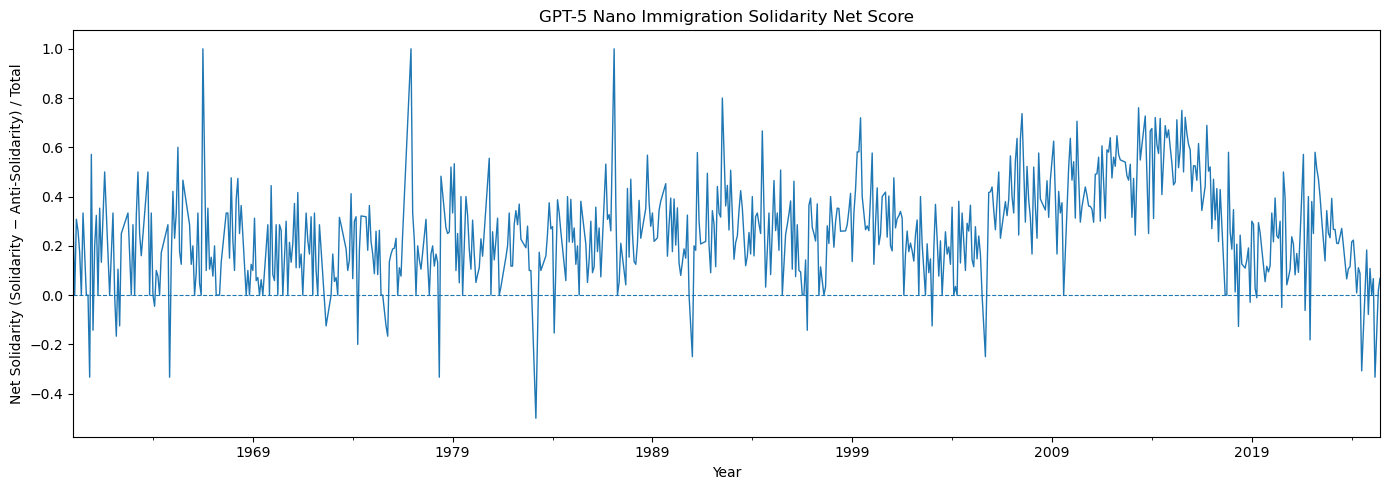

In [ ]:
def plot_monthly_net(monthly_net, output_path="gpt_sentiment_monthly.png"):
    fig, ax = plt.subplots(figsize=(14, 5))
    monthly_net.plot(ax=ax, linewidth=1)
    ax.axhline(0, linewidth=0.8, linestyle="--")
    ax.set_title("GPT-5 Nano Immigration Solidarity Net Score")
    ax.set_xlabel("Year")
    ax.set_ylabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
    plt.tight_layout()
    #plt.savefig(output_path, dpi=150)
    plt.show()

plot_monthly_net(monthly_net)

In [79]:
ann_df.columns

Index(['high_level', 'subtype', 'justification', 'error', 'warning',
       'raw_response', 'custom_id', 'speech_id', 'date', 'party', 'role',
       'governing_party', 'text', 'model', 'prompt_tokens',
       'completion_tokens', 'total_tokens', 'success', 'attempts', 'decade',
       'month'],
      dtype='object')

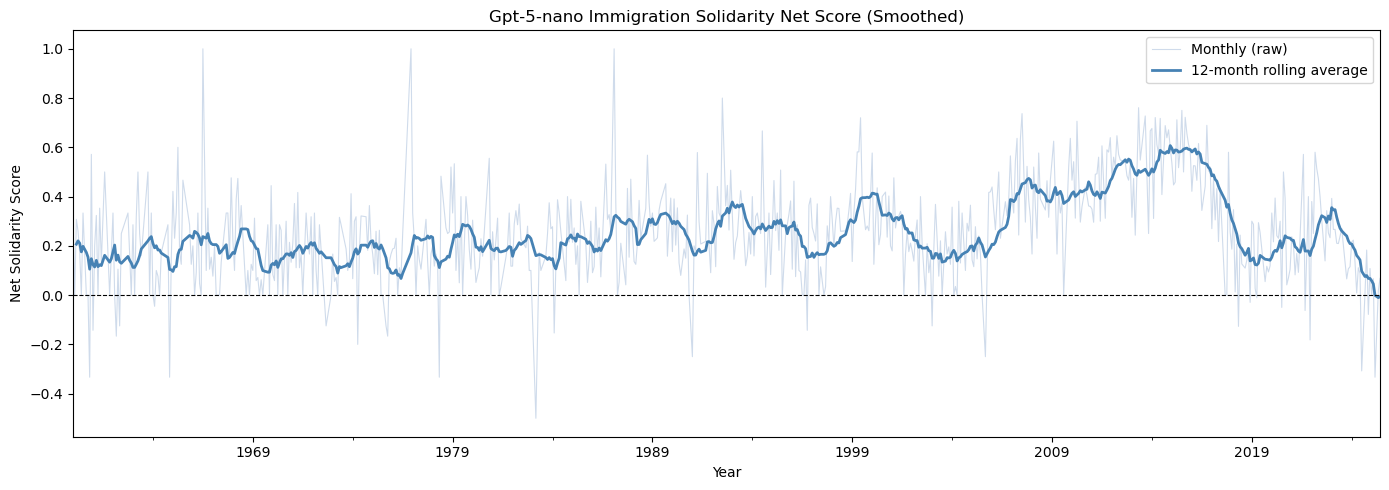

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))
monthly_net.plot(ax=ax, color="lightsteelblue", linewidth=0.8, alpha=0.6, label="Monthly (raw)")
monthly_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax, color="steelblue", linewidth=2, label="12-month rolling average"
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Gpt-5-nano Immigration Solidarity Net Score (Smoothed)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Solidarity Score")
ax.legend()
plt.tight_layout()
#plt.savefig("gpt_sentiment_smoothed.png", dpi=150)
plt.show()

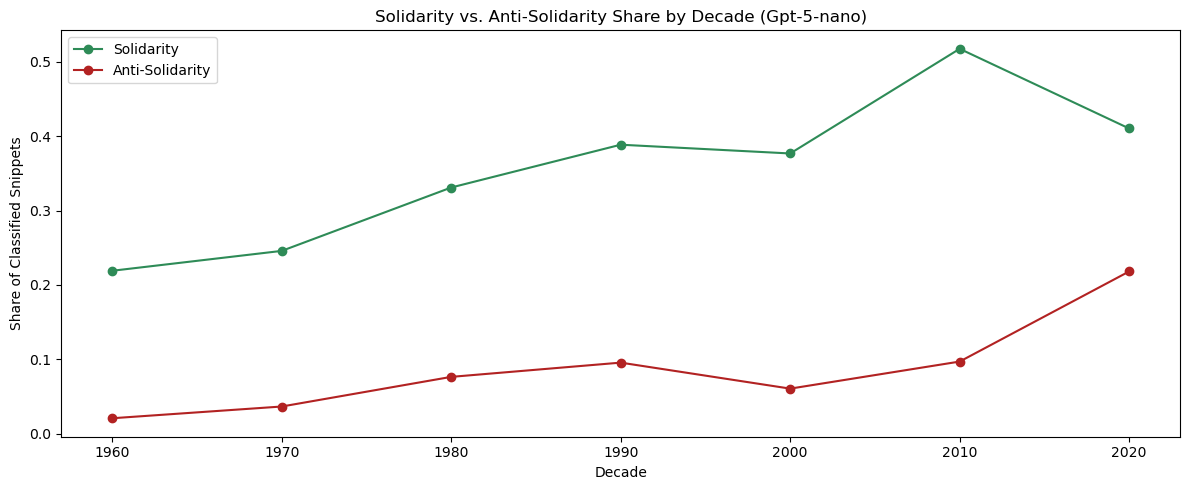

In [39]:
# decade_trend already computed in Step 8 — proportions of SOLIDARITY/ANTI-SOLIDARITY/MIXED/NONE per decade
fig, ax = plt.subplots(figsize=(12, 5))

decade_solidarity = decade_trend.get("SOLIDARITY", 0)
decade_antisolidarity = decade_trend.get("ANTI-SOLIDARITY", 0)

ax.plot(decade_trend.index, decade_solidarity, marker="o", color="seagreen", label="Solidarity")
ax.plot(decade_trend.index, decade_antisolidarity, marker="o", color="firebrick", label="Anti-Solidarity")
ax.set_title("Solidarity vs. Anti-Solidarity Share by Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Classified Snippets")
ax.legend()
plt.tight_layout()
#plt.savefig("gpt_decade_trend.png", dpi=150)
plt.show()

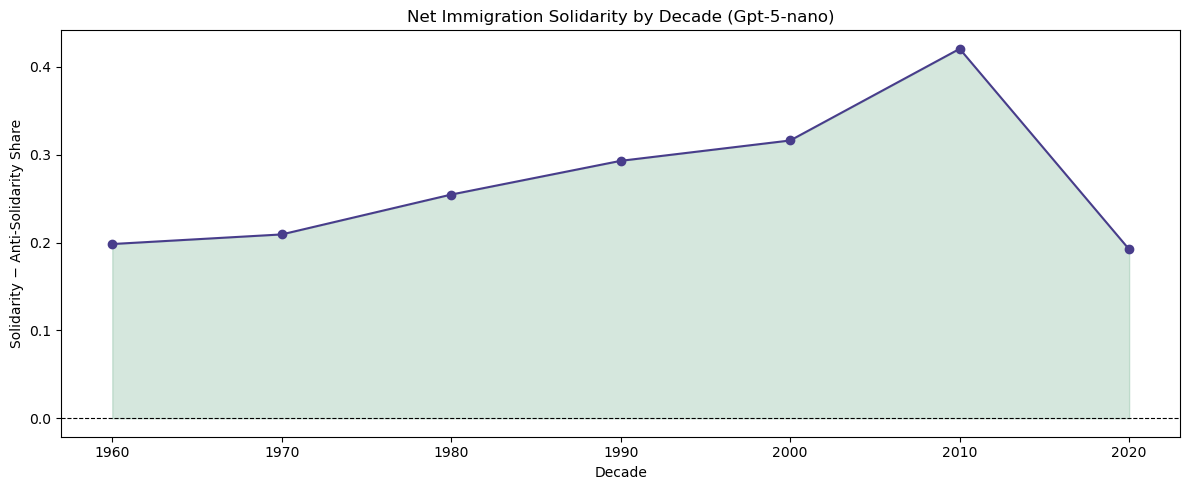

In [40]:
decade_net = decade_solidarity - decade_antisolidarity

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(decade_net.index, decade_net.values, marker="o", color="darkslateblue")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(decade_net.index, decade_net.values, 0,
                 where=(decade_net.values >= 0), color="seagreen", alpha=0.2)
ax.fill_between(decade_net.index, decade_net.values, 0,
                 where=(decade_net.values < 0), color="firebrick", alpha=0.2)
ax.set_title("Net Immigration Solidarity by Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Solidarity − Anti-Solidarity Share")
plt.tight_layout()
plt.savefig("gpt_decade_net.png", dpi=150)
plt.show()

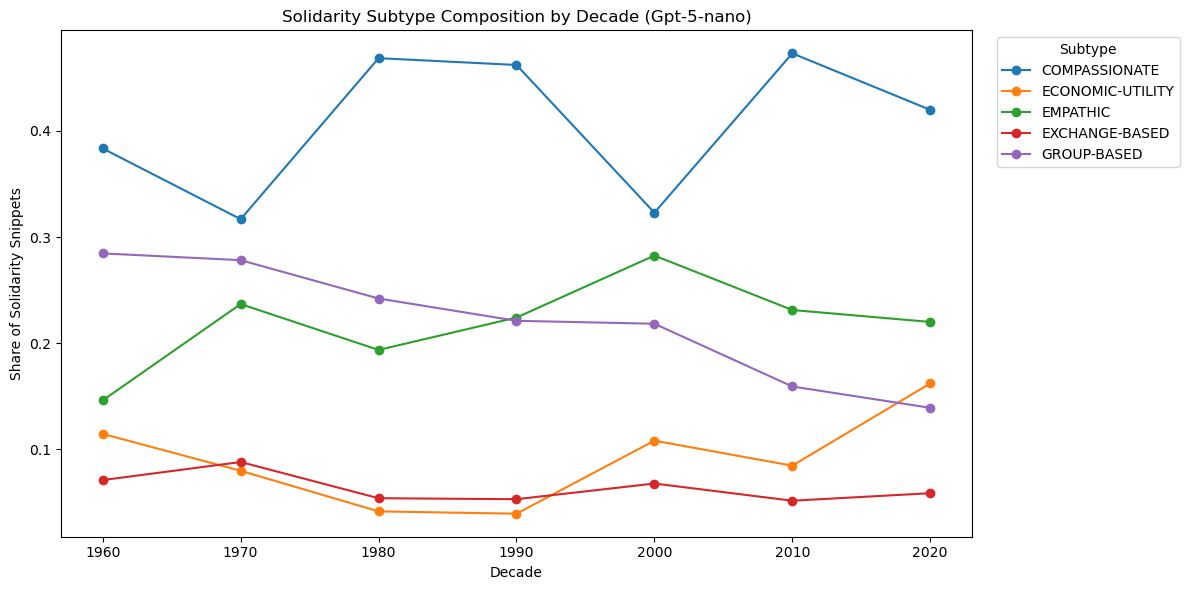

In [41]:
sol_subtype_trend = (
    ann_df[ann_df["high_level"] == "SOLIDARITY"]
    .groupby(["decade", "subtype"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

fig, ax = plt.subplots(figsize=(12, 6))
sol_subtype_trend.plot(ax=ax, marker="o")
ax.set_title("Solidarity Subtype Composition by Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Solidarity Snippets")
ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("gpt_solidarity_subtypes.png", dpi=150)
plt.show()

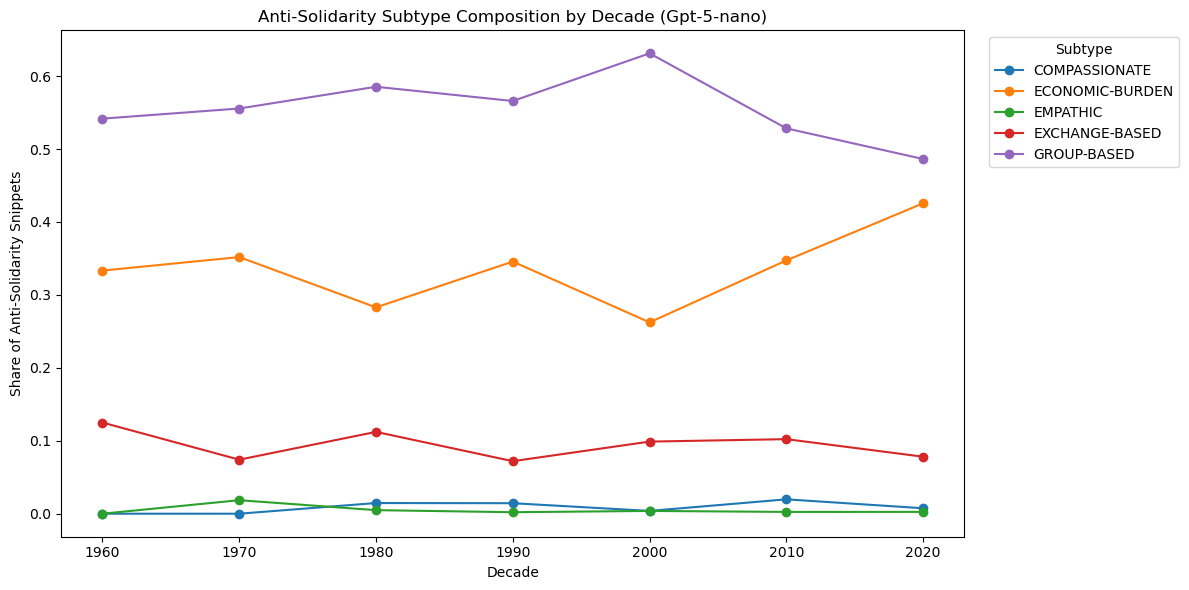

In [42]:
anti_subtype_trend = (
    ann_df[ann_df["high_level"] == "ANTI-SOLIDARITY"]
    .groupby(["decade", "subtype"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

fig, ax = plt.subplots(figsize=(12, 6))
anti_subtype_trend.plot(ax=ax, marker="o")
ax.set_title("Anti-Solidarity Subtype Composition by Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of Anti-Solidarity Snippets")
ax.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("gpt_antisolidarity_subtypes.png", dpi=150)
plt.show()

In [86]:
# Build a lookup: speech_id -> governing_party
lookup = df.set_index("speech_id")["governing_party"]

# Map onto ann_df by speech_id
ann_df["governing_party"] = ann_df["speech_id"].map(lookup)

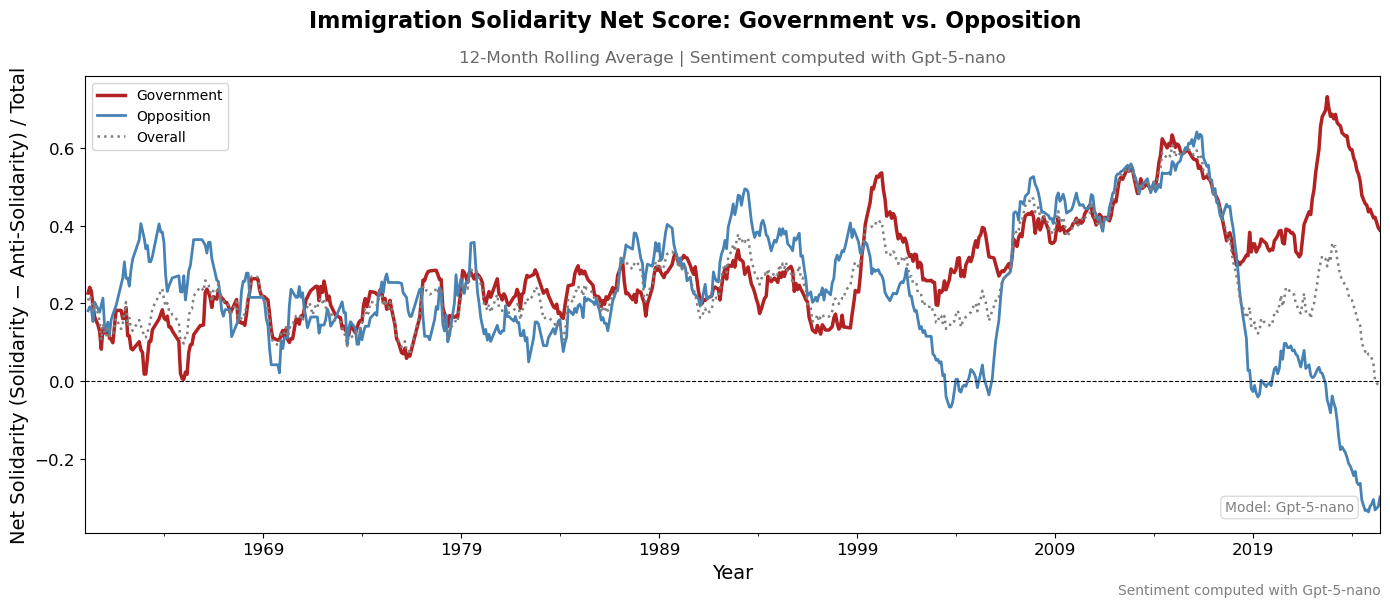

In [46]:

ann_df["month"] = ann_df["date"].dt.to_period("M")

def compute_monthly_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["month", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net

gov_net = compute_monthly_net(ann_df[ann_df['governing_party'] == 1.0])
opp_net = compute_monthly_net(ann_df[ann_df["governing_party"] == 0.0])

fig, ax = plt.subplots(figsize=(14, 6))
gov_net.rolling(window=12, min_periods=3).mean().plot(ax=ax, color="firebrick", linewidth=2.5, label="Government")
opp_net.rolling(window=12, min_periods=3).mean().plot(ax=ax, color="steelblue", linewidth=2, label="Opposition")
monthly_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax, color="gray", linewidth=1.8, label="Overall", linestyle=":"
)


ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# Main Title & Subtitle mentioning Doc2Vec
plt.suptitle(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
ax.set_title(
    "12-Month Rolling Average | Sentiment computed with Gpt-5-nano",
    fontsize=12,
    color="dimgray",
    pad=10,
)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Net Sentiment Score", fontsize=14)

# Tick labels
ax.tick_params(axis="both", which="major", labelsize=12)

# Legend font size
ax.legend(fontsize=12, loc="upper left")


ax.text(
    0.98,
    0.04,
    "Model: Gpt-5-nano",
    transform=ax.transAxes,
    fontsize=10,
    color="gray",
    ha="right",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.8,
    ),
)


ax.set_xlabel("Year")
ax.set_ylabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
ax.legend()
fig.text(
    0.99, 0.005,
    "Sentiment computed with Gpt-5-nano",
    ha="right", fontsize=10, color="gray"
)

plt.tight_layout()
#plt.savefig("gov_vs_opposition_monthly.png", dpi=150)
plt.show()

In [47]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
gov_net_complete = gov_net.reindex(full_period_range)
gov_net_filled = gov_net_complete.interpolate(method="linear")

In [48]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
opp_net_complete = opp_net.reindex(full_period_range)
opp_net_filled = opp_net_complete.interpolate(method="linear")

In [49]:
# Create complete PeriodIndex range
full_period_range = pd.period_range(
    start=gov_net.index.min(), end=gov_net.index.max(), freq="M"
)

# Reindex using periods directly
monthly_net_complete = monthly_net.reindex(full_period_range)
monthly_net_filled = monthly_net_complete.interpolate(method="linear")

In [ ]:
gov_net_filled.name = "gpt_sentiment_government"
opp_net_filled.name = "gpt_sentiment_opposition"
monthly_net_filled.name = "gtp_overall_sentiment"

sent_df = pd.concat([gov_net_filled, opp_net_filled, monthly_net_filled], axis=1)


sent_df = sent_df.reset_index().rename(columns={"index": "month"})


sent_df["month"] = sent_df["month"].astype(str)
sent_df["month"] = pd.to_datetime(sent_df["month"], format="%Y-%m")
sent_df = sent_df.sort_values("month")

sent_df.to_csv("./DATA/GptSentimentMonthlyVarGpt5Nano.csv", index=False)

In [73]:
parties = [
    'Cabinet',
    'FDP',
    'CDU/CSU',
    'SPD',
   # 'DP',
   # 'fraktionslos',
    'GRÜNE',
    'PDS',
    'LINKE',
    'AfD',
   # 'SPDCDU/CSU',
    'BSW'
]
ann_df = ann_df[ann_df["party"].isin(parties)]

In [74]:
# Number of rows/observations per party
ann_df["party"].value_counts()

party
CDU/CSU    7300
SPD        5990
Cabinet    4641
GRÜNE      3469
FDP        2834
LINKE      1898
AfD        1577
PDS         670
BSW          28
Name: count, dtype: int64

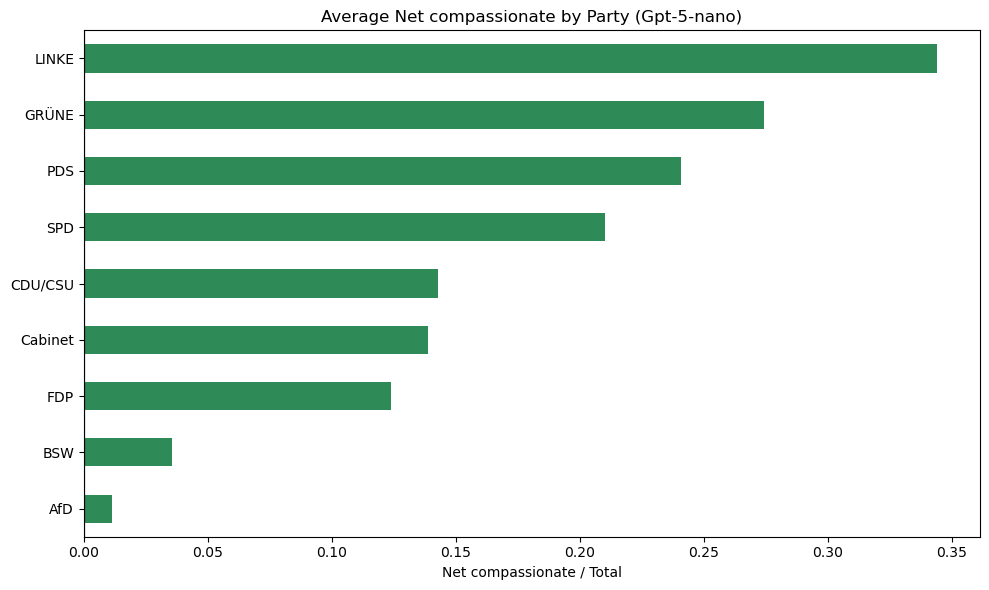

In [54]:
def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "subtype"]).size().unstack(fill_value=0)
    net = (counts.get('COMPASSIONATE', 0)) / counts.sum(axis=1)
    return net.sort_values()

party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net compassionate by Party (Gpt-5-nano)")
ax.set_xlabel("Net compassionate / Total")
ax.set_ylabel("")
plt.tight_layout()
#plt.savefig("party_net_sentiment.png", dpi=150)
plt.show()

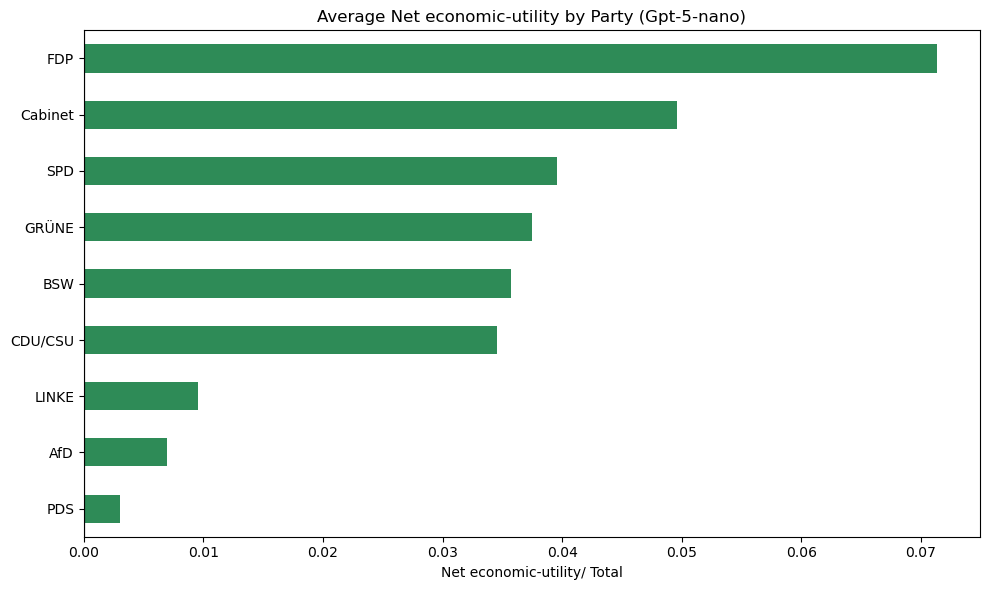

In [55]:
def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "subtype"]).size().unstack(fill_value=0)
    net = (counts.get('ECONOMIC-UTILITY', 0)) / counts.sum(axis=1)
    return net.sort_values()

party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net economic-utility by Party (Gpt-5-nano)")
ax.set_xlabel("Net economic-utility/ Total")
ax.set_ylabel("")
plt.tight_layout()
#plt.savefig("party_net_sentiment.png", dpi=150)
plt.show()

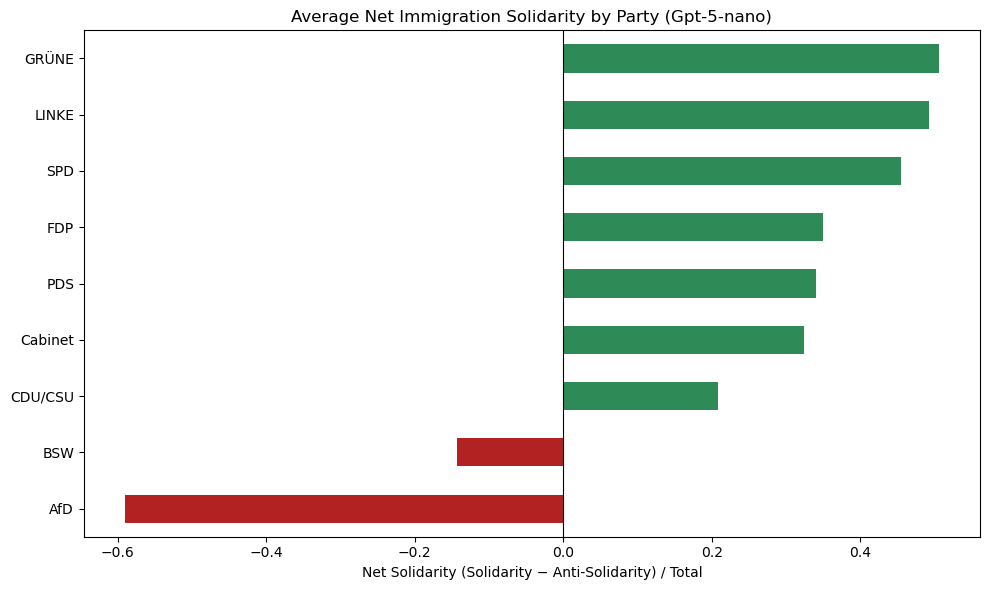

In [ ]:
def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net.sort_values()

party_net = compute_party_net(ann_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick" if v < 0 else "seagreen" for v in party_net.values]
party_net.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Average Net Immigration Solidarity by Party (Gpt-5-nano)")
ax.set_xlabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total")
ax.set_ylabel("")
plt.tight_layout()
#plt.savefig("party_net_sentiment.png", dpi=150)
plt.show()

### Gpt-5-nano SENTIMENT ANALYSIS — COMBINED DASHBOARD

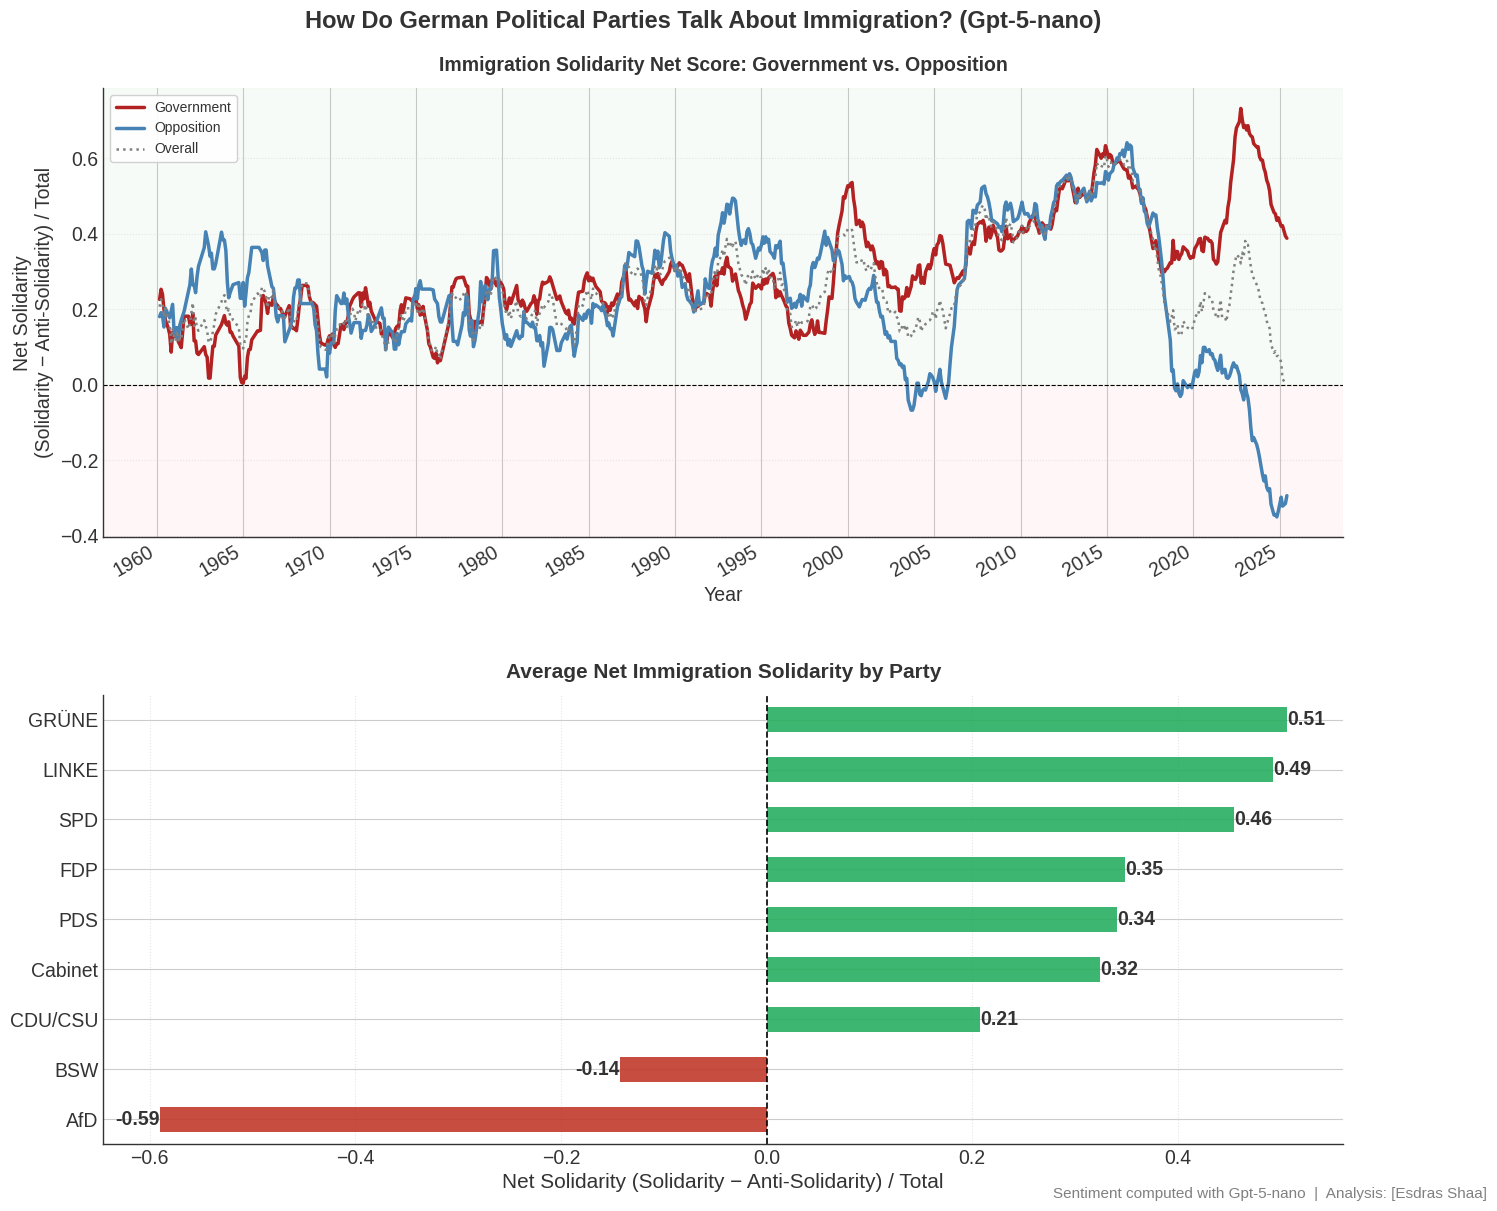

In [88]:

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["text.color"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"



ann_df["month"] = ann_df["date"].dt.to_period("M")



def compute_monthly_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["month", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    net.index = net.index.to_timestamp()  # convert PeriodIndex -> DatetimeIndex
    return net


def compute_party_net(df_subset: pd.DataFrame) -> pd.Series:
    counts = df_subset.groupby(["party", "high_level"]).size().unstack(fill_value=0)
    net = (counts.get("SOLIDARITY", 0) - counts.get("ANTI-SOLIDARITY", 0)) / counts.sum(axis=1)
    return net.sort_values()



gov_net     = compute_monthly_net(ann_df[ann_df["governing_party"] == 1.0])
opp_net     = compute_monthly_net(ann_df[ann_df["governing_party"] == 0.0])
overall_net = compute_monthly_net(ann_df)
party_net   = compute_party_net(ann_df)



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))



gov_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="firebrick", linewidth=2.5, label="Government", x_compat=True
)
opp_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="steelblue", linewidth=2.5, label="Opposition", x_compat=True
)
overall_net.rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="gray", linewidth=1.8, linestyle=":", label="Overall", x_compat=True
)


ymin, ymax = ax1.get_ylim()
ax1.axhspan(0, ymax, color="green", alpha=0.03)
ax1.axhspan(ymin, 0, color="red", alpha=0.03)
ax1.set_ylim(ymin, ymax)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.grid(axis="y", linestyle=":", alpha=0.4)

ax1.set_title(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=14, fontweight="bold", pad=12
)
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Net Solidarity\n(Solidarity − Anti-Solidarity) / Total", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.legend(fontsize=10, loc="upper left", frameon=True, framealpha=0.9)


ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))



colors = ["#c0392b" if val < 0 else "#27ae60" for val in party_net.values]
party_net.plot(kind="barh", color=colors, ax=ax2, alpha=0.9)

# Value labels at the end of each bar
for i, v in enumerate(party_net.values):
    ax2.text(
        v, i, f"{v:.2f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=14,
        color="#333333",
        fontweight="bold",
    )

ax2.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax2.grid(axis="x", linestyle=":", alpha=0.5)

ax2.set_title(
    "Average Net Immigration Solidarity by Party",
    fontsize=15, fontweight="bold", pad=12
)
ax2.set_xlabel("Net Solidarity (Solidarity − Anti-Solidarity) / Total", fontsize=15)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=14)



for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



fig.suptitle(
    "How Do German Political Parties Talk About Immigration? (Gpt-5-nano)",
    fontsize=17, fontweight="bold", y=0.995
)

plt.subplots_adjust(hspace=0.35, top=0.93, bottom=0.05)

fig.text(
    0.99, 0.005,
    "Sentiment computed with Gpt-5-nano  |  Analysis: [Esdras Shaa]",
    ha="right", fontsize=11, color="gray"
)

plt.show()

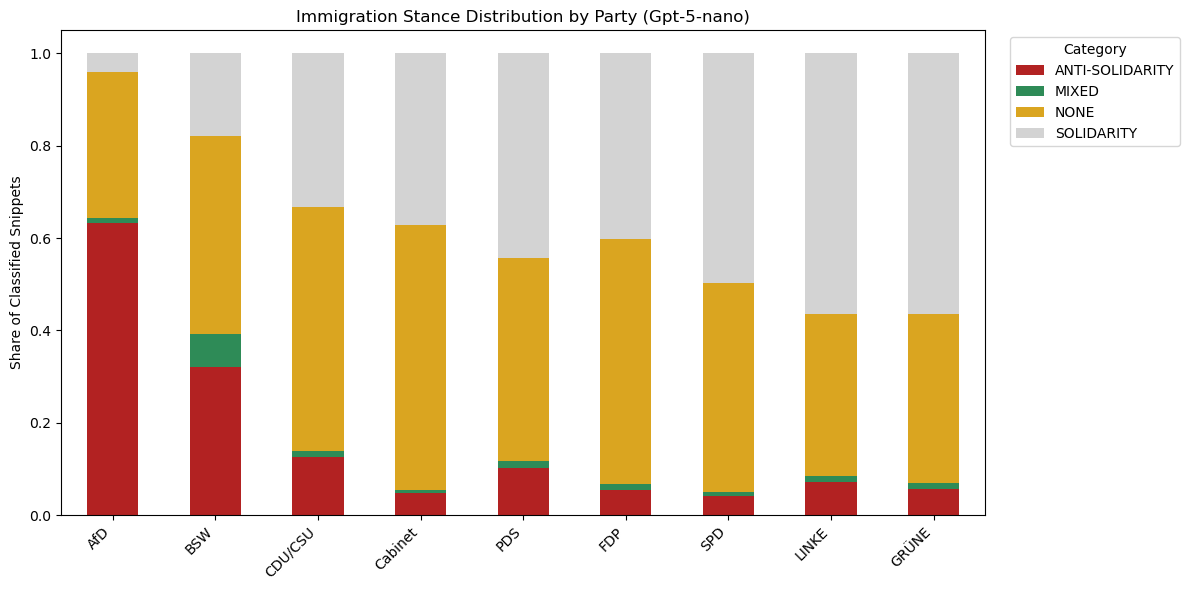

In [58]:
party_dist = (
    ann_df.groupby(["party", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

# order parties by net solidarity for a readable left-to-right gradient
party_order = party_net.index.tolist()
party_dist = party_dist.reindex(party_order)

fig, ax = plt.subplots(figsize=(12, 6))
party_dist.plot(kind="bar", stacked=True, ax=ax,
                  color=["firebrick", "seagreen", "goldenrod", "lightgray"])
ax.set_title("Immigration Stance Distribution by Party (Gpt-5-nano)")
ax.set_ylabel("Share of Classified Snippets")
ax.set_xlabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("party_distribution.png", dpi=150)
plt.show()

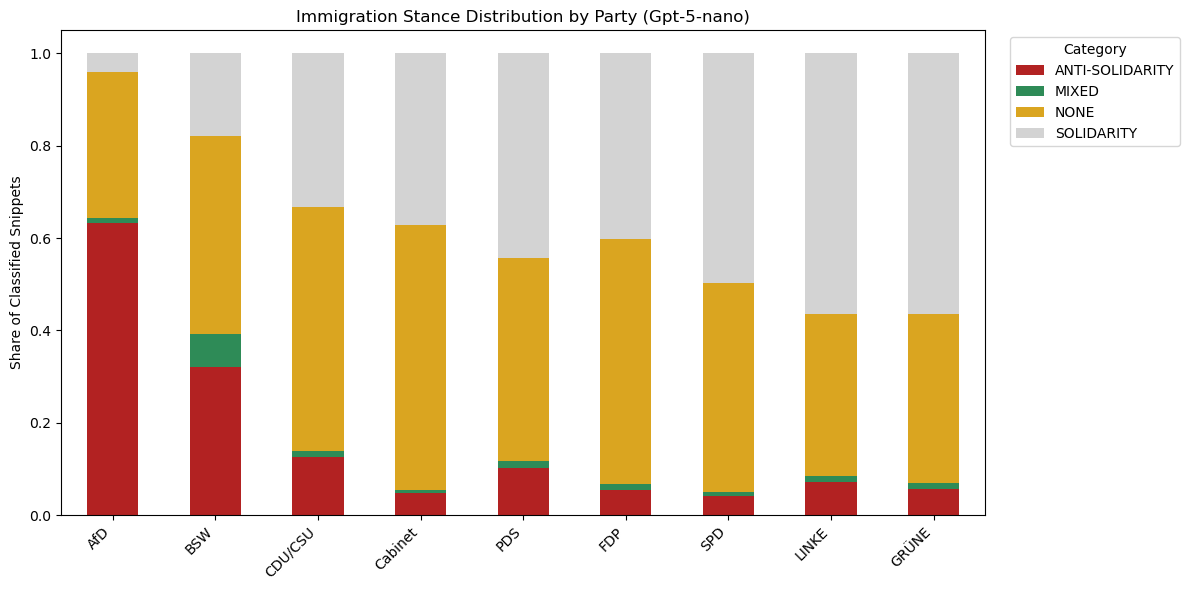

In [59]:
party_dist = (
    ann_df.groupby(["party", "high_level"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)

# order parties by net solidarity for a readable left-to-right gradient
party_order = party_net.index.tolist()
party_dist = party_dist.reindex(party_order)

fig, ax = plt.subplots(figsize=(12, 6))
party_dist.plot(kind="bar", stacked=True, ax=ax,
                  color=["firebrick", "seagreen", "goldenrod", "lightgray"])
ax.set_title("Immigration Stance Distribution by Party (Gpt-5-nano)")
ax.set_ylabel("Share of Classified Snippets")
ax.set_xlabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("party_distribution.png", dpi=150)
plt.show()

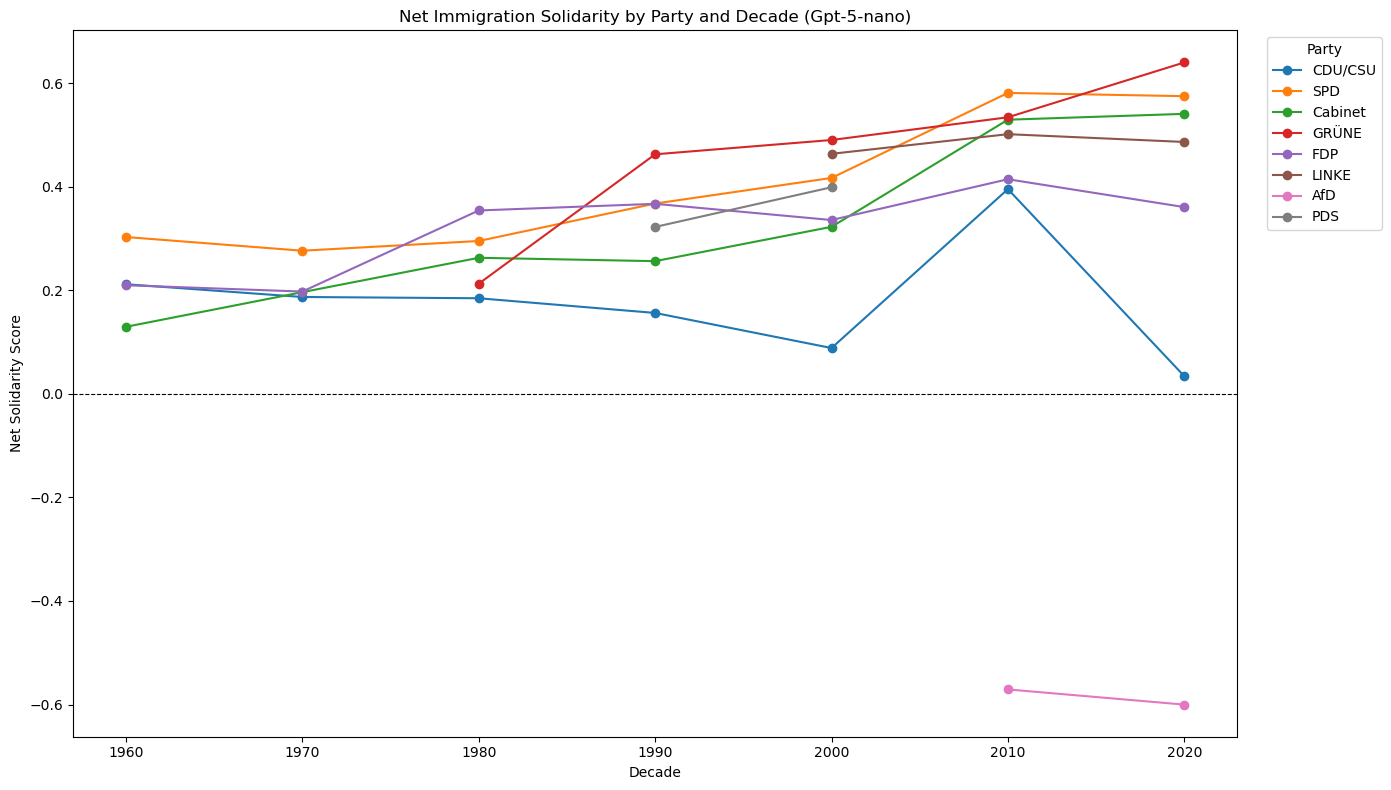

In [66]:
ann_df["decade"] = (ann_df["date"].dt.year // 10) * 10

party_decade_counts = (
    ann_df.groupby(["decade", "party", "high_level"]).size()
    .unstack(fill_value=0)
)
party_decade_net = (
    (party_decade_counts.get("SOLIDARITY", 0) - party_decade_counts.get("ANTI-SOLIDARITY", 0))
    / party_decade_counts.sum(axis=1)
).unstack("party")

# focus on parties with enough data to be meaningful — drop very sparse ones
min_snippets_per_party = 30
party_counts_total = ann_df["party"].value_counts()
main_parties = party_counts_total[party_counts_total >= min_snippets_per_party].index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
party_decade_net[main_parties].plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Net Immigration Solidarity by Party and Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Net Solidarity Score")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("party_decade_trend.png", dpi=150)
plt.show()

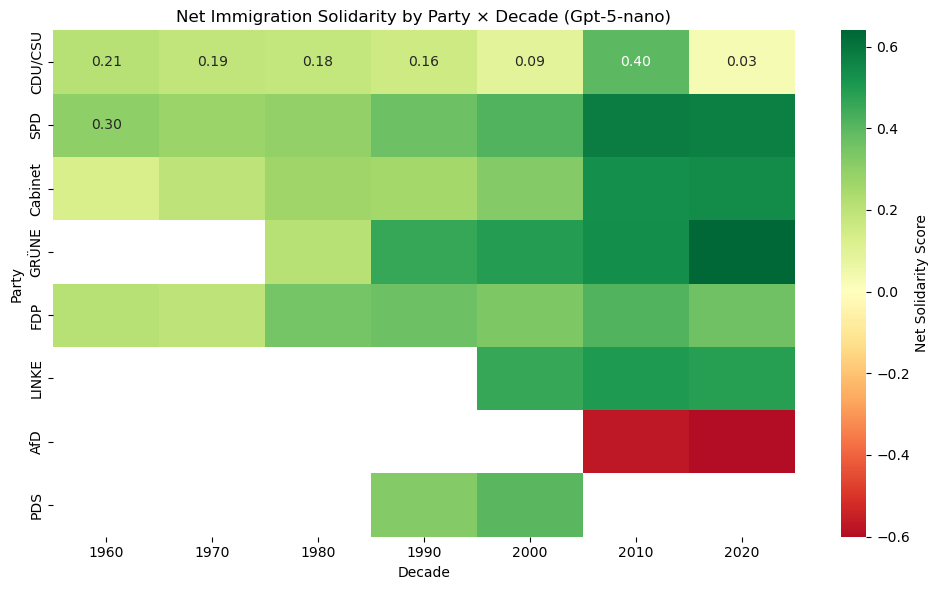

In [62]:
import seaborn as sns  # pip install seaborn --break-system-packages, if not already available

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    party_decade_net[main_parties].T,
    cmap="RdYlGn", center=0, annot=True, fmt=".2f",
    cbar_kws={"label": "Net Solidarity Score"}, ax=ax,
)
ax.set_title("Net Immigration Solidarity by Party × Decade (Gpt-5-nano)")
ax.set_xlabel("Decade")
ax.set_ylabel("Party")
plt.tight_layout()
plt.savefig("party_decade_heatmap.png", dpi=150)
plt.show()